# Analyse mit SHAP


### Import der Bibs und Module

In [1]:
import sys
import numpy as np
import shap
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import os

# Findet den absoluten Pfad zur Projektwurzel (eine Ebene über dem 'notebooks' Ordner)
# Holt den Pfad zum Ordner, in dem das Notebook liegt (z.B. notebooks/)
NOTEBOOK_DIR = Path.cwd() 
# Fügt den Elternordner (Computer-Vision_Soccer/) zum Suchpfad hinzu
PROJECT_ROOT = NOTEBOOK_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
# -----------------------------------

# Projekt-Module
from src.config import *
from src.models.modelManager import ModelManager
from src.visualization.visualize import visualize_detections, show_grid

# Initiale Konfiguration für SHAP Plots
shap.initjs()

print("Imports erfolgreich und SHAP initialisiert.")

/home/smartrollerz/XAI/Computer-Vision_Soccer/xai-venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
ModelDependencyMissing: Your `inference` configuration does not support SAM3 model. Install SAM3 dependencies and set CORE_MODEL_SAM3_ENABLED to True.
ModelDependencyMissing: Your `inference` configuration does not support GroundingDINO model. Use pip install 'inference[grounding-dino]' to install missing requirements.To suppress this warning, set CORE_MODEL_GROUNDINGDINO_ENABLED to False.


Imports erfolgreich und SHAP initialisiert.


### Laden von Modell und Daten
Für die vergleichbarkeit nutze ich erstmal dieselben wie bei LIME

In [2]:
# 1. Modell laden
model_manager = ModelManager()
model_manager.load_model()

# 2. Bilder Pfade laden
total_images = sorted(list(DATASET_PATH.rglob("*.jpg")))
print(f"Anzahl Bilder im Dataset: {len(total_images)}")

# 3. Wir nutzen dieselben Indizes wie in der LIME Analyse für Vergleichbarkeit
IMAGES_INDICES = [4298, 1390, 362, 3029, 4247, 726, 4257, 4859, 1288]

# Kleiner Helper um das Bild direkt als Numpy Array zu laden (für SHAP)
def get_image_by_index(index):
    try:
        img_path = total_images[index]
        return Image.open(img_path)
    except IndexError:
        print(f"Index {index} nicht gefunden!")
        return None

print(f"Analysiere folgende Indizes: {IMAGES_INDICES}")

⬇ Lade Modell: football-ball-detection-rejhg/4
  (Verwendet Cache falls bereits heruntergeladen)


✓ Modell geladen
Anzahl Bilder im Dataset: 4948
Analysiere folgende Indizes: [4298, 1390, 362, 3029, 4247, 726, 4257, 4859, 1288]


### Wrapper Funktion
Bild wird als NUMPY Array maskiert.

In [3]:
def detection_wrapper(numpy_images):
    """
    Wandelt SHAP's Numpy-Input in Input für den ModelManager um
    und gibt die Konfidenz für die Klasse 'ball' zurück.
    
    Args:
        numpy_images: Ein Batch von Bildern als Numpy Array (N, H, W, C)
    
    Returns:
        Ein Numpy Array mit den Scores (N,)
    """
    results = []
    
    for img_arr in numpy_images:
        # SHAP übergibt oft normalisierte Daten (0-1) oder uint8 (0-255)
        if img_arr.max() <= 1.0:
            img_arr = (img_arr * 255).astype(np.uint8)
        else:
            img_arr = img_arr.astype(np.uint8)
            
        # Konvertierung zu PIL für deinen ModelManager
        pil_img = Image.fromarray(img_arr)
        
        # Inference durchführen
        # Wir fangen Fehler ab, falls das Bild durch Maskierung "kaputt" ist
        try:
            inference_result = model_manager.infer(pil_img)
            
            # Wir suchen die höchste Confidence für einen Ball im Bild
            # Wenn kein Ball gefunden wurde, ist der Score 0.0
            max_confidence = 0.0
            
            if hasattr(inference_result, 'predictions'):
                for pred in inference_result.predictions:
                    # Optional: Prüfen ob class_name == 'ball' (falls du mehr Klassen hättest)
                    if pred.confidence > max_confidence:
                        max_confidence = pred.confidence
            
            results.append(max_confidence)
            
        except Exception as e:
            # Fallback falls Inference fehlschlägt
            results.append(0.0)
            
    return np.array(results)

print("Wrapper-Funktion definiert.")

Wrapper-Funktion definiert.


### Analysefunktion

In [4]:
def analyze_with_shap(image_index, max_evals=500):
    # 1. Bild laden
    original_img = get_image_by_index(image_index)
    if original_img is None: return

    # In Numpy wandeln
    img_numpy = np.array(original_img)
    
    print(f"\nStarte SHAP Analyse für Bild Index {image_index}...")
    print(f"Bildgröße: {img_numpy.shape}")
    
    # 2. Masker definieren
    # "inpaint_telea" füllt maskierte Bereiche intelligent auf (besser als Grau/Schwarz)
    # Das hilft, Artefakte zu vermeiden.
    masker = shap.maskers.Image("inpaint_telea", img_numpy.shape)

    # 3. Explainer erstellen
    # Wir übergeben unsere Wrapper-Funktion und den Masker
    explainer = shap.Explainer(detection_wrapper, masker)

    # 4. Shap Values berechnen
    # max_evals bestimmt, wie oft das Modell abgefragt wird. 
    # Höher = genauer, aber langsamer. 
    shap_values = explainer(
        img_numpy[np.newaxis, ...], # SHAP erwartet eine Batch-Dimension (1, H, W, C)
        max_evals=max_evals,
        batch_size=10 # Batch processing um API Calls zu sparen (falls möglich)
    )

    # 5. Visualisierung
    # Zeige zuerst das Original mit Detection
    print("Original Detection:")
    res = model_manager.infer(original_img)
    annotated = visualize_detections(original_img, res)
    plt.figure(figsize=(8, 6))
    plt.imshow(annotated)
    plt.axis('off')
    plt.title(f"Original Prediction (Index {image_index})")
    plt.show()

    print("SHAP Erklärung (Rot = Positiver Einfluss, Blau = Negativer Einfluss):")
    # shap.image_plot zeigt die Pixel-Wichtigkeit
    shap.image_plot(shap_values)

# Durchführung der Analyse


Starte SHAP Analyse für Bild Index 4298...
Bildgröße: (640, 640, 3)


PartitionExplainer explainer: 2it [21:13, 1273.93s/it]             


Original Detection:


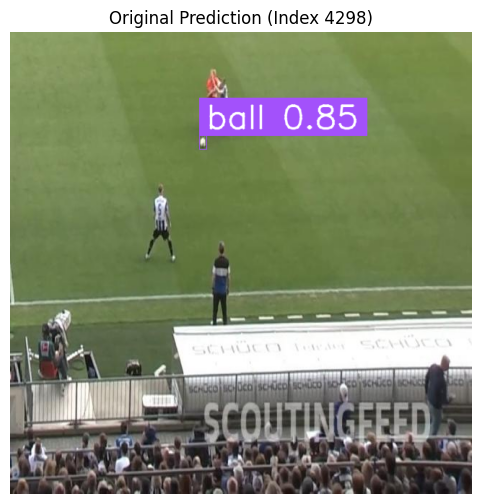

SHAP Erklärung (Rot = Positiver Einfluss, Blau = Negativer Einfluss):


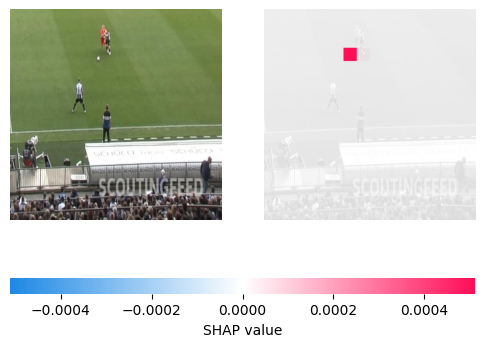

In [6]:
analyze_with_shap(IMAGES_INDICES[0], max_evals=500)

Damit weiß ich grob um die Region, was tatsächlich die Ballregion ist. Nun ist es Interessant zu sehen, inwiefern dern Kontext dort relevant ist (z.B. Beine). Zwar könnte man die Durchläufe einfach nur erhöhen, allerdings würde das sehr viel Rechenleistung benötigen. Deswegen werde ich erstmal eine Region des Bildes betrachten.

Analysiere Ausschnitt: (600, 100, 1200, 700)
Bildgröße für SHAP: (600, 600, 3)


PartitionExplainer explainer: 2it [35:35, 2135.55s/it]             


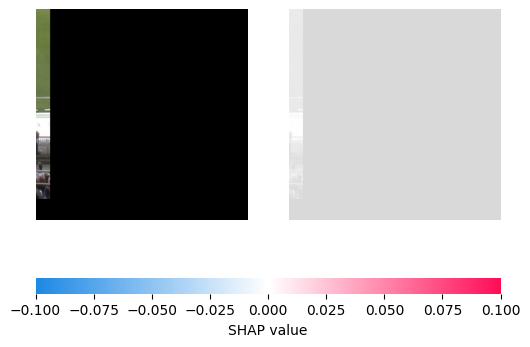

In [8]:
# Format: (Links, Oben, Rechts, Unten)
# Bereich um Spieler und Ball
roi = (600, 100, 1200, 700) 

analyze_with_shap(IMAGES_INDICES[0], max_evals=1000, crop_coords=roi)

In [ ]:
analyze_with_shap(IMAGES_INDICES[0], max_evals=1500)